<a href="https://colab.research.google.com/github/FarhadNuri/BN-Fact-Check/blob/main/notebooks/Day4_Label_Encoding_%2B_Augmentation_%2B_Final_Split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Day1_setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE = '/content/drive/MyDrive/BanglaFakeNews'
print("Base path set:", BASE)

Base path set: /content/drive/MyDrive/BanglaFakeNews


In [ ]:
import os

folders = [
    f'{BASE}/data/raw',
    f'{BASE}/data/processed',
    f'{BASE}/notebooks',
    f'{BASE}/models',
    f'{BASE}/app/templates',
    f'{BASE}/app/static',
    f'{BASE}/reports/figures',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'✅ Created: {folder}')

print('\nAll folders ready.')

✅ Created: /content/drive/MyDrive/BanglaFakeNews/data/raw
✅ Created: /content/drive/MyDrive/BanglaFakeNews/data/processed
✅ Created: /content/drive/MyDrive/BanglaFakeNews/notebooks
✅ Created: /content/drive/MyDrive/BanglaFakeNews/models
✅ Created: /content/drive/MyDrive/BanglaFakeNews/app/templates
✅ Created: /content/drive/MyDrive/BanglaFakeNews/app/static
✅ Created: /content/drive/MyDrive/BanglaFakeNews/reports/figures

All folders ready.


In [ ]:
# Fix httpx version conflict completely
!pip install httpx==0.27.0 -q
!pip install huggingface_hub --upgrade -q
!pip install transformers --upgrade -q
!pip install bnlp-toolkit -q
!pip install imbalanced-learn -q
!pip install deep-translator -q

print("✅ Done. Now restart runtime.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mcp 1.26.0 requires httpx>=0.27.1, but you have httpx 0.27.0 which is incompatible.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.27.0 which is incompatible.
google-genai 1.66.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 118.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 80.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━

In [ ]:
!pip install transformers -q
print("✅ Transformers installed.")

✅ Transformers installed.


In [ ]:


import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from transformers import AutoTokenizer

print("✅ All imports successful.")
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not found — go to Runtime → Change runtime type → T4 GPU")

✅ All imports successful.
PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [ ]:
# Run this cell to upload train.csv and validate.csv from your computer
from google.colab import files

print("Select train.csv when the upload dialog opens...")
uploaded = files.upload()

for filename, content in uploaded.items():
    dest = f'{BASE}/data/raw/{filename}'
    with open(dest, 'wb') as f:
        f.write(content)
    print(f'✅ Saved {filename} → {dest}')

Select train.csv when the upload dialog opens...


Saving train.csv to train.csv
✅ Saved train.csv → /content/drive/MyDrive/BanglaFakeNews/data/raw/train.csv


In [ ]:
# Run this cell to upload train.csv and validate.csv from your computer
from google.colab import files

print("Select train.csv when the upload dialog opens...")
uploaded = files.upload()

for filename, content in uploaded.items():
    dest = f'{BASE}/data/raw/{filename}'
    with open(dest, 'wb') as f:
        f.write(content)
    print(f'✅ Saved {filename} → {dest}')

Select train.csv when the upload dialog opens...


Saving validate.csv to validate.csv
✅ Saved validate.csv → /content/drive/MyDrive/BanglaFakeNews/data/raw/validate.csv


In [ ]:
train = pd.read_csv(f'{BASE}/data/raw/train.csv')
validate = pd.read_csv(f'{BASE}/data/raw/validate.csv')

print("=== TRAIN ===")
print(f"Shape: {train.shape}")
print(f"Columns: {train.columns.tolist()}")
print(f"Label counts:\n{train['label'].value_counts()}")
print(f"Nulls: {train.isnull().sum().to_dict()}")
print(f"Duplicates: {train.duplicated().sum()}")

print("\n=== VALIDATE ===")
print(f"Shape: {validate.shape}")
print(f"Label counts:\n{validate['label'].value_counts()}")


=== TRAIN ===
Shape: (2700, 2)
Columns: ['text', 'label']
Label counts:
label
Neutral         1166
Personal         856
Geopolitical     401
Religious        158
Political        119
Name: count, dtype: int64
Nulls: {'text': 0, 'label': 0}
Duplicates: 33

=== VALIDATE ===
Shape: (900, 2)
Label counts:
label
Neutral         433
Personal        276
Geopolitical    110
Religious        44
Political        37
Name: count, dtype: int64


In [ ]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"✅ Random seed set to {SEED}")

✅ Random seed set to 42


In [ ]:
import json

config = {
    "seed": 42,
    "base_path": BASE,
    "num_labels": 5,
    "label_classes": ["Geopolitical", "Neutral", "Personal", "Political", "Religious"],
    "model_name": "sagorsarker/bangla-bert-base",
    "max_length": 128,
    "batch_size": 16,
    "learning_rate": 2e-5,
    "epochs": 4,
    "train_size": 2700,
    "val_size": 450,
    "test_size": 450
}

with open(f'{BASE}/models/config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("✅ Config saved to models/config.json")
print(json.dumps(config, indent=4))

✅ Config saved to models/config.json
{
    "seed": 42,
    "base_path": "/content/drive/MyDrive/BanglaFakeNews",
    "num_labels": 5,
    "label_classes": [
        "Geopolitical",
        "Neutral",
        "Personal",
        "Political",
        "Religious"
    ],
    "model_name": "sagorsarker/bangla-bert-base",
    "max_length": 128,
    "batch_size": 16,
    "learning_rate": 2e-05,
    "epochs": 4,
    "train_size": 2700,
    "val_size": 450,
    "test_size": 450
}


#Day2_EDA

In [ ]:
train = pd.read_csv(f'{BASE}/data/raw/train.csv')
validate = pd.read_csv(f'{BASE}/data/raw/validate.csv')

print("=== TRAIN ===")
print(f"Shape: {train.shape}")
print(f"Columns: {train.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(train.head(3))

print("\n=== VALIDATE ===")
print(f"Shape: {validate.shape}")
print(f"\nFirst 3 rows:")
print(validate.head(3))

=== TRAIN ===
Shape: (2700, 2)
Columns: ['text', 'label']

First 3 rows:
                                                text         label
0            ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই।      Religious
1  দাদা! নৌকা কিন্তু চলে না। এমাসে কম দিয়েছেন ১৯ ...  Geopolitical
2  দম্ভ ও অহংকার পতনের মূল, জাতি দম্ভ দেখেছে এখন ...  Geopolitical

=== VALIDATE ===
Shape: (900, 2)

First 3 rows:
                                                text     label
0                  রানু মন্ডল নিজেকে শেষ করে দিলেন।   Personal
1  এদিকে রুপার বুকে তিল আছে, এটা আমার ভাইয়া কিভাব...  Personal
2  তাদের পরিকল্পনা ছিল, নিজেদের ভিডিও করে পর্ণগ্র...  Personal


In [ ]:
print("=== TRAIN LABEL DISTRIBUTION ===")
train_counts = train['label'].value_counts()
print(train_counts)
print(f"\nImbalance ratio (largest/smallest): {train_counts.max() / train_counts.min():.1f}x")

print("\n=== VALIDATE LABEL DISTRIBUTION ===")
val_counts = validate['label'].value_counts()
print(val_counts)

=== TRAIN LABEL DISTRIBUTION ===
label
Neutral         1166
Personal         856
Geopolitical     401
Religious        158
Political        119
Name: count, dtype: int64

Imbalance ratio (largest/smallest): 9.8x

=== VALIDATE LABEL DISTRIBUTION ===
label
Neutral         433
Personal        276
Geopolitical    110
Religious        44
Political        37
Name: count, dtype: int64


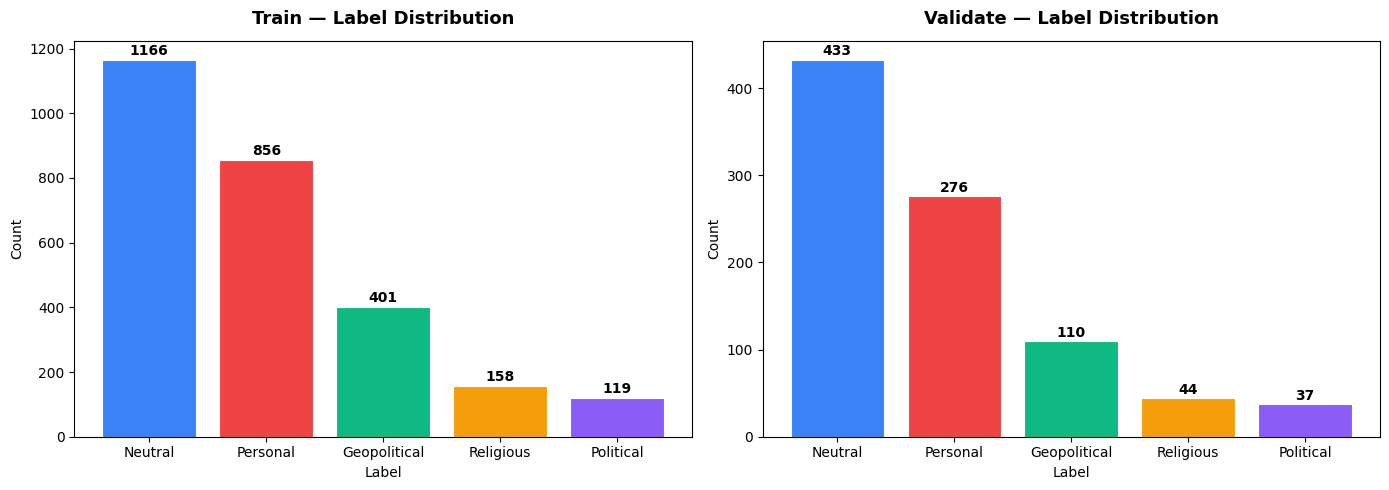

✅ Saved to reports/figures/label_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
colors_train = ['#3b82f6','#ef4444','#10b981','#f59e0b','#8b5cf6']
axes[0].bar(train_counts.index, train_counts.values, color=colors_train, edgecolor='white', linewidth=0.8)
axes[0].set_title('Train — Label Distribution', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 15, str(count), ha='center', fontweight='bold', fontsize=10)

# Validate
axes[1].bar(val_counts.index, val_counts.values, color=colors_train, edgecolor='white', linewidth=0.8)
axes[1].set_title('Validate — Label Distribution', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
for i, (label, count) in enumerate(val_counts.items()):
    axes[1].text(i, count + 5, str(count), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/figures/label_distribution.png")

In [ ]:
print("=== NULLS ===")
print("Train:")
print(train.isnull().sum())
print("\nValidate:")
print(validate.isnull().sum())

print("\n=== DUPLICATES ===")
train_dups = train.duplicated().sum()
val_dups = validate.duplicated().sum()
print(f"Train duplicates:    {train_dups}")
print(f"Validate duplicates: {val_dups}")

if train_dups > 0:
    print(f"\n⚠️ {train_dups} duplicate rows found in train — will drop in Day 3")

=== NULLS ===
Train:
text     0
label    0
dtype: int64

Validate:
text     0
label    0
dtype: int64

=== DUPLICATES ===
Train duplicates:    33
Validate duplicates: 7

⚠️ 33 duplicate rows found in train — will drop in Day 3


In [ ]:
# Add word count column
train['word_count'] = train['text'].str.split().str.len()
validate['word_count'] = validate['text'].str.split().str.len()

print("=== TRAIN — Word Count Stats per Class ===")
stats = train.groupby('label')['word_count'].describe()[['min','mean','50%','max','std']]
stats.columns = ['Min', 'Mean', 'Median', 'Max', 'Std']
stats = stats.round(1)
print(stats)

print("\n=== Overall ===")
print(f"Min words:    {train['word_count'].min()}")
print(f"Max words:    {train['word_count'].max()}")
print(f"Mean words:   {train['word_count'].mean():.1f}")
print(f"Median words: {train['word_count'].median():.1f}")

=== TRAIN — Word Count Stats per Class ===
              Min  Mean  Median   Max  Std
label                                     
Geopolitical  4.0  11.0    10.0  32.0  4.4
Neutral       4.0  11.9    11.0  33.0  4.7
Personal      4.0  10.7    10.0  29.0  4.2
Political     4.0  10.5     9.0  25.0  5.0
Religious     5.0  10.9    10.0  24.0  4.0

=== Overall ===
Min words:    4
Max words:    33
Mean words:   11.3
Median words: 10.0


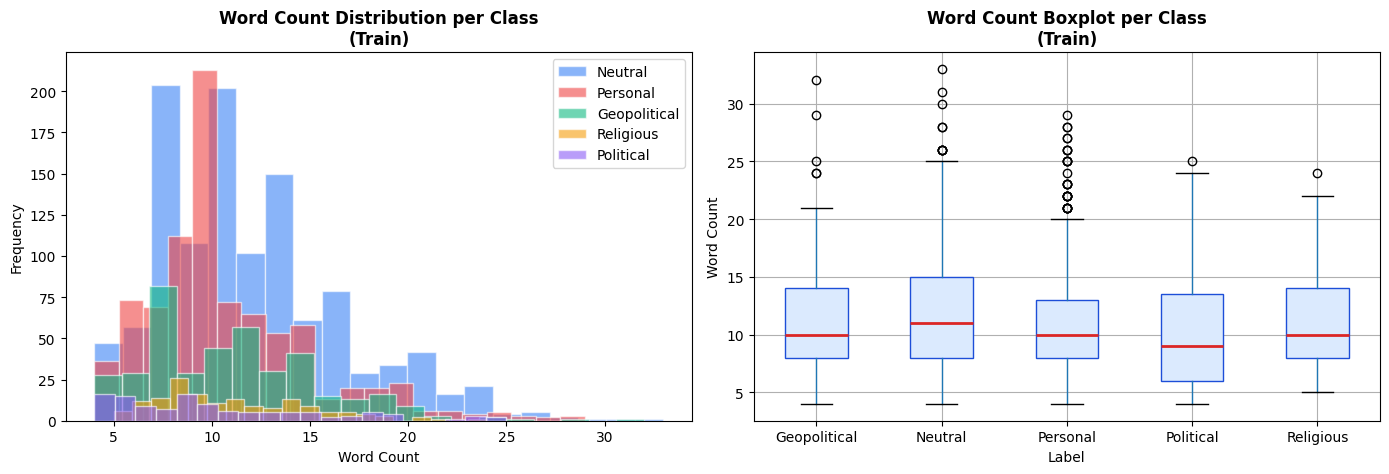

✅ Saved to reports/figures/text_length_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_colors = {
    'Neutral': '#3b82f6',
    'Personal': '#ef4444',
    'Geopolitical': '#10b981',
    'Religious': '#f59e0b',
    'Political': '#8b5cf6'
}

# Histogram per class
for label, color in label_colors.items():
    subset = train[train['label'] == label]['word_count']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Word Count Distribution per Class\n(Train)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot per class
train.boxplot(column='word_count', by='label', ax=axes[1],
              patch_artist=True,
              boxprops=dict(facecolor='#dbeafe', color='#1d4ed8'),
              medianprops=dict(color='#dc2626', linewidth=2))
axes[1].set_title('Word Count Boxplot per Class\n(Train)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{BASE}/reports/figures/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/figures/text_length_distribution.png")

In [ ]:
print("=== SAMPLE TEXTS PER CLASS ===\n")

for label in train['label'].unique():
    print(f"{'='*50}")
    print(f"  CLASS: {label}")
    print(f"{'='*50}")
    samples = train[train['label'] == label]['text'].sample(2, random_state=42).values
    for i, sample in enumerate(samples, 1):
        print(f"  Sample {i}: {sample[:150]}...")
    print()

=== SAMPLE TEXTS PER CLASS ===

  CLASS: Religious
  Sample 1: নাস্তিক ধর্মের গোপনীয়তা যা মুসলিমদের কাছে নাস্তিকরা গোপন করতে চায়, নাস্তিকদের জন্য যা অপরিহার্য। ...
  Sample 2: মুসলিম হয়েও কালীপূজা উদ্বোধন করলেন সাকিব। ...

  CLASS: Geopolitical
  Sample 1: আওয়ামীলীগের অবস্থা হচ্ছে বন্দুক ধারী রংবাজ এর মত, জায়গা বরাবর ধরলেই চিত পটাং।...
  Sample 2: গোটা পশ্চিমবঙ্গটাই বর্তমানে অনশন নগরী, মমতা সরকারকে কাঁক্ষ জয় ব্যানার্জীর। ...

  CLASS: Neutral
  Sample 1: লাভ ম্যারেজ না এরেঞ্জ ম্যারেজ? ভাই আমারে কেউ বিয়ে করতে রাজি হইলে তাতেই আলহামদুলিল্লাহ। ...
  Sample 2: ইউরোপের ফুটবল স্টেডিয়াম আর বাংলাদেশের ফুটবল স্টেডিয়াম। ...

  CLASS: Personal
  Sample 1: আনুশকা দিহান এবং স্কুল বন্ধের দাবি নিয়ে কঠিন হুংকার দিলেন মুফতি আশরাফ আলী আল মাদানী। ...
  Sample 2: এই জিনিস কি তোর বাপের সম্পত্তি । ...

  CLASS: Political
  Sample 1: মৃতপ্রায় খাদিজার সাথে নির্লজ্জ সেলফি, মানবতার সাতে আর কত উপহাস করবে এই বেহায়ালীগ নেত্রীরা। ...
  Sample 2: দুই মন্ত্রীর মন্তব্যে বিচার বিভাগ স্তম্ভিত ও হতবাক, বিচার বিভাগ এবং প্র

In [ ]:
print("=== CLASS IMBALANCE ANALYSIS ===\n")

total = len(train)
print(f"{'Label':<15} {'Count':>8} {'% of Total':>12} {'Status':>12}")
print("-" * 50)

for label, count in train_counts.items():
    pct = (count / total) * 100
    if pct > 35:
        status = "Dominant ⚠️"
    elif pct > 20:
        status = "Majority"
    elif pct > 10:
        status = "Medium"
    else:
        status = "Minority 🔴"
    print(f"{label:<15} {count:>8} {pct:>11.1f}% {status:>12}")

print("-" * 50)
print(f"{'TOTAL':<15} {total:>8}")
print(f"\nImbalance ratio: {train_counts.max() / train_counts.min():.1f}x")
print("(anything above 3x needs handling)")

=== CLASS IMBALANCE ANALYSIS ===

Label              Count   % of Total       Status
--------------------------------------------------
Neutral             1166        43.2%  Dominant ⚠️
Personal             856        31.7%     Majority
Geopolitical         401        14.9%       Medium
Religious            158         5.9%   Minority 🔴
Political            119         4.4%   Minority 🔴
--------------------------------------------------
TOTAL               2700

Imbalance ratio: 9.8x
(anything above 3x needs handling)


In [ ]:
# Remove the helper column before saving
train_clean = train.drop(columns=['word_count'])
validate_clean = validate.drop(columns=['word_count'])

# Save as-is for now (cleaning happens Day 3)
train_clean.to_csv(f'{BASE}/data/processed/train_eda_checked.csv', index=False)
validate_clean.to_csv(f'{BASE}/data/processed/validate_eda_checked.csv', index=False)

print("✅ EDA-checked files saved to data/processed/")
print(f"   train_eda_checked.csv    → {len(train_clean)} rows")
print(f"   validate_eda_checked.csv → {len(validate_clean)} rows")

✅ EDA-checked files saved to data/processed/
   train_eda_checked.csv    → 2700 rows
   validate_eda_checked.csv → 900 rows


In [ ]:
summary = {
    'train_rows': len(train),
    'validate_rows': len(validate),
    'train_duplicates': int(train.duplicated().sum()),
    'train_nulls': int(train.isnull().sum().sum()),
    'validate_nulls': int(validate.isnull().sum().sum()),
    'label_counts_train': train['label'].value_counts().to_dict(),
    'label_counts_validate': validate['label'].value_counts().to_dict(),
    'imbalance_ratio': round(float(train_counts.max() / train_counts.min()), 2),
    'word_count_min': int(train['word_count'].min()),
    'word_count_max': int(train['word_count'].max()),
    'word_count_mean': round(float(train['word_count'].mean()), 1),
}

import json
with open(f'{BASE}/reports/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("✅ EDA summary saved to reports/eda_summary.json")
print("\n=== SUMMARY ===")
print(json.dumps(summary, indent=4))

✅ EDA summary saved to reports/eda_summary.json

=== SUMMARY ===
{
    "train_rows": 2700,
    "validate_rows": 900,
    "train_duplicates": 33,
    "train_nulls": 0,
    "validate_nulls": 0,
    "label_counts_train": {
        "Neutral": 1166,
        "Personal": 856,
        "Geopolitical": 401,
        "Religious": 158,
        "Political": 119
    },
    "label_counts_validate": {
        "Neutral": 433,
        "Personal": 276,
        "Geopolitical": 110,
        "Religious": 44,
        "Political": 37
    },
    "imbalance_ratio": 9.8,
    "word_count_min": 4,
    "word_count_max": 33,
    "word_count_mean": 11.3
}


#Day3_text_cleaning_pipeline

In [ ]:
!pip install bnlp-toolkit -q

from bnlp import CleanText
print("✅ bnlp-toolkit loaded.")

punkt not found. downloading...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ bnlp-toolkit loaded.


In [ ]:
train = pd.read_csv(f'{BASE}/data/processed/train_eda_checked.csv')
validate = pd.read_csv(f'{BASE}/data/processed/validate_eda_checked.csv')

print(f"Train shape:    {train.shape}")
print(f"Validate shape: {validate.shape}")
print(f"\nTrain sample:\n{train['text'].iloc[0]}")

Train shape:    (2700, 2)
Validate shape: (900, 2)

Train sample:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই। 


In [ ]:
before = len(train)
train = train.drop_duplicates().reset_index(drop=True)
after = len(train)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Dropped:     {before - after} duplicate rows")

Rows before: 2700
Rows after:  2667
Dropped:     33 duplicate rows


In [ ]:
import re

sample = train['text'].iloc[0]
print("ORIGINAL:")
print(sample)
print()

# Step 1 — Remove HTML tags
step1 = re.sub(r'<.*?>', '', sample)
print("STEP 1 — Remove HTML tags:")
print(step1)
print()

# Step 2 — Remove URLs
step2 = re.sub(r'http\S+|www\S+', '', step1)
print("STEP 2 — Remove URLs:")
print(step2)
print()

# Step 3 — Remove English characters and digits
step3 = re.sub(r'[A-Za-z0-9]', '', step2)
print("STEP 3 — Remove English chars and digits:")
print(step3)
print()

# Step 4 — Keep only Bangla Unicode + spaces
# Bangla Unicode range: \u0980–\u09FF
step4 = re.sub(r'[^\u0980-\u09FF\s]', '', step3)
print("STEP 4 — Keep only Bangla Unicode:")
print(step4)
print()

# Step 5 — Normalize whitespace
step5 = re.sub(r'\s+', ' ', step4).strip()
print("STEP 5 — Normalize whitespace:")
print(step5)

ORIGINAL:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই। 

STEP 1 — Remove HTML tags:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই। 

STEP 2 — Remove URLs:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই। 

STEP 3 — Remove English chars and digits:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই। 

STEP 4 — Keep only Bangla Unicode:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই 

STEP 5 — Normalize whitespace:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই


In [ ]:
def clean_text(text):
    # Guard: if text is missing return empty string
    if pd.isna(text):
        return ''

    # Convert to string just in case
    text = str(text)

    # Step 1 — Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Step 2 — Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3 — Remove English characters and digits
    text = re.sub(r'[A-Za-z0-9]', '', text)

    # Step 4 — Keep only Bangla Unicode characters and spaces
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)

    # Step 5 — Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Quick test
test = "আমাদের <b>দেশ</b> বাংলাদেশ। Visit http://example.com for details. Bangladesh 123"
print("Input:  ", test)
print("Output: ", clean_text(test))

Input:   আমাদের <b>দেশ</b> বাংলাদেশ। Visit http://example.com for details. Bangladesh 123
Output:  আমাদের দেশ বাংলাদেশ


In [ ]:
print("Cleaning train dataset...")
train['cleaned'] = train['text'].apply(clean_text)
print(f"✅ Train cleaned — {len(train)} rows")

print("\nCleaning validate dataset...")
validate['cleaned'] = validate['text'].apply(clean_text)
print(f"✅ Validate cleaned — {len(validate)} rows")

# Show before vs after for 5 samples
print("\n=== BEFORE vs AFTER (5 samples) ===")
for i in range(5):
    print(f"\n[{i+1}] BEFORE: {train['text'].iloc[i][:100]}")
    print(f"    AFTER:  {train['cleaned'].iloc[i][:100]}")

Cleaning train dataset...
✅ Train cleaned — 2667 rows

Cleaning validate dataset...
✅ Validate cleaned — 900 rows

=== BEFORE vs AFTER (5 samples) ===

[1] BEFORE: ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই। 
    AFTER:  ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই

[2] BEFORE: দাদা! নৌকা কিন্তু চলে না। এমাসে কম দিয়েছেন ১৯ হাজার কিউসেক পানি। নদীতে পানির কি দরকার! বন্ধুত্বে তো 
    AFTER:  দাদা নৌকা কিন্তু চলে না এমাসে কম দিয়েছেন ১৯ হাজার কিউসেক পানি নদীতে পানির কি দরকার বন্ধুত্বে তো জোয়া

[3] BEFORE: দম্ভ ও অহংকার পতনের মূল, জাতি দম্ভ দেখেছে এখন পতন দেখতে চায়। 
    AFTER:  দম্ভ ও অহংকার পতনের মূল জাতি দম্ভ দেখেছে এখন পতন দেখতে চায়

[4] BEFORE: বিএনপি জামাতের আগুন সন্ত্রাস। রাজধানীতে বাসে আগুন দেয়ার ঘাঁনয় বিএনপি জামাতের ১০ জন আটক।
    AFTER:  বিএনপি জামাতের আগুন সন্ত্রাস রাজধানীতে বাসে আগুন দেয়ার ঘাঁনয় বিএনপি জামাতের ১০ জন আটক

[5] BEFORE: পুলিশকে ২০ দলের হুশিয়ারী বেশি বাড়াবাড়ি করলে তাদের বাড়ীতে বাড়ীতে আক্রমন করা হবে। 
    AFTER:  পুলিশকে ২০ দলের হুশিয়ারী বেশি বাড়াবাড়ি করলে তাদের বাড়ীতে বাড়ীতে আক্র

In [ ]:
# Some texts might become empty after removing all non-Bangla content
train_empty = train[train['cleaned'].str.strip() == '']
validate_empty = validate[validate['cleaned'].str.strip() == '']

print(f"Empty texts after cleaning — Train:    {len(train_empty)}")
print(f"Empty texts after cleaning — Validate: {len(validate_empty)}")

if len(train_empty) > 0:
    print("\nEmpty train rows:")
    print(train_empty[['text', 'label']])
    # Drop empty rows
    train = train[train['cleaned'].str.strip() != ''].reset_index(drop=True)
    print(f"✅ Dropped {len(train_empty)} empty rows from train")

if len(validate_empty) > 0:
    print("\nEmpty validate rows:")
    print(validate_empty[['text', 'label']])
    validate = validate[validate['cleaned'].str.strip() != ''].reset_index(drop=True)
    print(f"✅ Dropped {len(validate_empty)} empty rows from validate")

Empty texts after cleaning — Train:    0
Empty texts after cleaning — Validate: 0


In [ ]:
train['cleaned_word_count'] = train['cleaned'].str.split().str.len()
validate['cleaned_word_count'] = validate['cleaned'].str.split().str.len()

print("=== CLEANED TEXT LENGTH STATS (Train) ===")
print(train.groupby('label')['cleaned_word_count'].describe()[
    ['min','mean','50%','max']
].round(1))

print(f"\nOverall mean word count after cleaning: {train['cleaned_word_count'].mean():.1f}")
print(f"Texts with less than 3 words: {(train['cleaned_word_count'] < 3).sum()}")

=== CLEANED TEXT LENGTH STATS (Train) ===
              min  mean   50%   max
label                              
Geopolitical  4.0  10.9  10.0  32.0
Neutral       4.0  11.9  11.0  33.0
Personal      4.0  10.7  10.0  29.0
Political     4.0  10.5   9.0  25.0
Religious     5.0  10.8  10.0  24.0

Overall mean word count after cleaning: 11.2
Texts with less than 3 words: 0


In [ ]:
print("=== LABEL DISTRIBUTION AFTER CLEANING ===")
print("\nTrain:")
print(train['label'].value_counts())
print("\nValidate:")
print(validate['label'].value_counts())

# Compare with original
print("\n✅ Verify these match Day 2 counts (minus 33 duplicates from train)")

=== LABEL DISTRIBUTION AFTER CLEANING ===

Train:
label
Neutral         1163
Personal         828
Geopolitical     399
Religious        158
Political        119
Name: count, dtype: int64

Validate:
label
Neutral         433
Personal        276
Geopolitical    110
Religious        44
Political        37
Name: count, dtype: int64

✅ Verify these match Day 2 counts (minus 33 duplicates from train)


In [ ]:
# Keep only the columns we need
train_save = train[['text', 'cleaned', 'label']].copy()
validate_save = validate[['text', 'cleaned', 'label']].copy()

train_save.to_csv(f'{BASE}/data/processed/train_cleaned.csv', index=False)
validate_save.to_csv(f'{BASE}/data/processed/validate_cleaned.csv', index=False)

print("✅ Saved:")
print(f"   train_cleaned.csv    → {len(train_save)} rows")
print(f"   validate_cleaned.csv → {len(validate_save)} rows")

# Show final sample
print("\n=== FINAL SAMPLE ===")
print(train_save[['text','cleaned','label']].head(3).to_string())

✅ Saved:
   train_cleaned.csv    → 2667 rows
   validate_cleaned.csv → 900 rows

=== FINAL SAMPLE ===
                                                                                                              text                                                                                                     cleaned         label
0                                                                          ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই।                                                                        ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই     Religious
1  দাদা! নৌকা কিন্তু চলে না। এমাসে কম দিয়েছেন ১৯ হাজার কিউসেক পানি। নদীতে পানির কি দরকার! বন্ধুত্বে তো জোয়ার বইছে।  দাদা নৌকা কিন্তু চলে না এমাসে কম দিয়েছেন ১৯ হাজার কিউসেক পানি নদীতে পানির কি দরকার বন্ধুত্বে তো জোয়ার বইছে  Geopolitical
2                                                    দম্ভ ও অহংকার পতনের মূল, জাতি দম্ভ দেখেছে এখন পতন দেখতে চায়।                                                   দম্ভ ও অহংকার পতনের মূল

In [ ]:
# Save the function as a .py file so Member 2 and Member 3 can import it
clean_text_code = '''
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\\S+|www\\S+", "", text)
    text = re.sub(r"[A-Za-z0-9]", "", text)
    text = re.sub(r"[^\\u0980-\\u09FF\\s]", "", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text
'''

with open(f'{BASE}/notebooks/clean_text.py', 'w', encoding='utf-8') as f:
    f.write(clean_text_code)

print("✅ clean_text.py saved to notebooks/")
print("Member 2 and 3 can import it with:")
print("  exec(open(f'{BASE}/notebooks/clean_text.py').read())")

✅ clean_text.py saved to notebooks/
Member 2 and 3 can import it with:
  exec(open(f'{BASE}/notebooks/clean_text.py').read())


#Day4 - Label Encoding + Augmentation + Final Split

In [ ]:
import pandas as pd
import numpy as np
import json
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [ ]:
train = pd.read_csv(f'{BASE}/data/processed/train_cleaned.csv')
validate = pd.read_csv(f'{BASE}/data/processed/validate_cleaned.csv')

print("=== TRAIN ===")
print(f"Shape: {train.shape}")
print(f"Columns: {train.columns.tolist()}")
print(f"Label counts:\n{train['label'].value_counts()}")

print("\n=== VALIDATE ===")
print(f"Shape: {validate.shape}")
print(f"Label counts:\n{validate['label'].value_counts()}")

=== TRAIN ===
Shape: (2667, 3)
Columns: ['text', 'cleaned', 'label']
Label counts:
label
Neutral         1163
Personal         828
Geopolitical     399
Religious        158
Political        119
Name: count, dtype: int64

=== VALIDATE ===
Shape: (900, 3)
Label counts:
label
Neutral         433
Personal        276
Geopolitical    110
Religious        44
Political        37
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()

# Fit on train labels and transform both
train['label_enc'] = le.fit_transform(train['label'])
validate['label_enc'] = le.transform(validate['label'])

print("=== LABEL ENCODING MAP ===")
for i, cls in enumerate(le.classes_):
    count = (train['label'] == cls).sum()
    print(f"  {i} → {cls:<15} ({count} samples)")

# Save label classes for Member 2 and Member 3
np.save(f'{BASE}/models/label_classes.npy', le.classes_)
print(f"\n✅ Label classes saved to models/label_classes.npy")
print(f"Classes: {le.classes_.tolist()}")

=== LABEL ENCODING MAP ===
  0 → Geopolitical    (399 samples)
  1 → Neutral         (1163 samples)
  2 → Personal        (828 samples)
  3 → Political       (119 samples)
  4 → Religious       (158 samples)

✅ Label classes saved to models/label_classes.npy
Classes: ['Geopolitical', 'Neutral', 'Personal', 'Political', 'Religious']


In [ ]:
print("=== SAMPLE — TEXT, LABEL, ENCODED ===")
for label in train['label'].unique():
    sample = train[train['label'] == label].iloc[0]
    print(f"\nLabel:   {sample['label']}")
    print(f"Encoded: {sample['label_enc']}")
    print(f"Text:    {sample['cleaned'][:80]}...")

=== SAMPLE — TEXT, LABEL, ENCODED ===

Label:   Religious
Encoded: 4
Text:    ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই...

Label:   Geopolitical
Encoded: 0
Text:    দাদা নৌকা কিন্তু চলে না এমাসে কম দিয়েছেন ১৯ হাজার কিউসেক পানি নদীতে পানির কি দরক...

Label:   Neutral
Encoded: 1
Text:    চুইংগাম চিবানোর সময় পাকস্থলিও কনফিউজড হয়ে যায় ৩ ঘন্টা ধরে কী চিবুচ্ছে এখনো নিচে ...

Label:   Personal
Encoded: 2
Text:    গ্রাম থেকে এসেই চাচাতো ভাই চুরি করা শুরু করছে দেখে আব্বু আর চাচাতো ভাই...

Label:   Political
Encoded: 3
Text:    কোটা আন্দোলনের সেই চার নেতাই সক্রিয় নেতাই সক্রিয় শিবির কর্মী...


In [ ]:
!pip install deep-translator -q
from deep_translator import GoogleTranslator
print("✅ deep-translator loaded.")

✅ deep-translator loaded.


In [ ]:
def back_translate(text):
    try:
        # Step 1: Bangla → English
        english = GoogleTranslator(source='bn', target='en').translate(text)
        # Step 2: English → Bangla
        bangla = GoogleTranslator(source='en', target='bn').translate(english)
        return bangla
    except Exception as e:
        print(f"Translation failed: {e}")
        return text  # return original if translation fails

# Test on one sample
sample_text = train[train['label'] == 'Religious']['cleaned'].iloc[0]
print("ORIGINAL:")
print(sample_text)
print("\nBACK-TRANSLATED:")
print(back_translate(sample_text))

ORIGINAL:
ধর্মীয় বইগুলোকে বলা হচ্ছে উগ্রবাদী বই

BACK-TRANSLATED:
ধর্মীয় বইকে বলা হয় মৌলবাদী বই


In [ ]:
print("=== CLASS COUNTS BEFORE AUGMENTATION ===")
counts = train['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<15}: {count}")

print(f"\nTarget after augmentation:")
print(f"  Religious    → 400  (currently {counts.get('Religious', 0)})")
print(f"  Political    → 400  (currently {counts.get('Political', 0)})")
print(f"  Geopolitical → 600  (currently {counts.get('Geopolitical', 0)})")

=== CLASS COUNTS BEFORE AUGMENTATION ===
  Neutral        : 1163
  Personal       : 828
  Geopolitical   : 399
  Religious      : 158
  Political      : 119

Target after augmentation:
  Religious    → 400  (currently 158)
  Political    → 400  (currently 119)
  Geopolitical → 600  (currently 399)


In [ ]:
def augment_class(df, label, target_count, le):
    """
    Augments a specific class using back-translation
    until it reaches target_count samples.
    """
    current = df[df['label'] == label].copy()
    current_count = len(current)
    needed = target_count - current_count

    if needed <= 0:
        print(f"  {label}: already has {current_count} samples, no augmentation needed.")
        return pd.DataFrame()

    print(f"  {label}: {current_count} → {target_count} (generating {needed} new samples)")

    augmented_rows = []
    attempts = 0
    max_attempts = needed * 3  # try 3x more than needed in case some fail

    # Cycle through existing samples repeatedly if needed
    source_texts = current['cleaned'].tolist()
    source_idx = 0

    while len(augmented_rows) < needed and attempts < max_attempts:
        original_text = source_texts[source_idx % len(source_texts)]
        translated = back_translate(original_text)

        # Only keep if translation actually changed the text
        if translated != original_text and len(translated.strip()) > 5:
            augmented_rows.append({
                'text': original_text,
                'cleaned': translated,
                'label': label,
                'label_enc': le.transform([label])[0]
            })

        source_idx += 1
        attempts += 1

    print(f"    ✅ Generated {len(augmented_rows)} new samples")
    return pd.DataFrame(augmented_rows)

In [ ]:
print("Starting augmentation — this will take 10–20 minutes...\n")

aug_religious    = augment_class(train, 'Religious',    400, le)
aug_political    = augment_class(train, 'Political',    400, le)
aug_geopolitical = augment_class(train, 'Geopolitical', 600, le)

print("\n✅ Augmentation complete.")
print(f"  Religious generated:    {len(aug_religious)}")
print(f"  Political generated:    {len(aug_political)}")
print(f"  Geopolitical generated: {len(aug_geopolitical)}")

Starting augmentation — this will take 10–20 minutes...

  Religious: 158 → 400 (generating 242 new samples)
    ✅ Generated 242 new samples
  Political: 119 → 400 (generating 281 new samples)
    ✅ Generated 281 new samples
  Geopolitical: 399 → 600 (generating 201 new samples)
    ✅ Generated 201 new samples

✅ Augmentation complete.
  Religious generated:    242
  Political generated:    281
  Geopolitical generated: 201


In [ ]:
train_augmented = pd.concat([
    train,
    aug_religious,
    aug_political,
    aug_geopolitical
], ignore_index=True)

print("=== CLASS COUNTS AFTER AUGMENTATION ===")
new_counts = train_augmented['label'].value_counts()
for label, count in new_counts.items():
    original = counts.get(label, 0)
    added = count - original
    print(f"  {label:<15}: {original} → {count}  (+{added} new samples)")

print(f"\nTotal rows: {len(train)} → {len(train_augmented)}")
print(f"New imbalance ratio: {new_counts.max() / new_counts.min():.1f}x")

=== CLASS COUNTS AFTER AUGMENTATION ===
  Neutral        : 1163 → 1163  (+0 new samples)
  Personal       : 828 → 828  (+0 new samples)
  Geopolitical   : 399 → 600  (+201 new samples)
  Religious      : 158 → 400  (+242 new samples)
  Political      : 119 → 400  (+281 new samples)

Total rows: 2667 → 3391
New imbalance ratio: 2.9x


In [ ]:
train_augmented = train_augmented.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print(f"✅ Dataset shuffled — {len(train_augmented)} rows")
print(f"\nFirst 5 rows after shuffle:")
print(train_augmented[['label', 'label_enc']].head())

✅ Dataset shuffled — 3391 rows

First 5 rows after shuffle:
       label  label_enc
0   Personal          2
1   Personal          2
2  Religious          4
3    Neutral          1
4   Personal          2


In [ ]:
val_df, test_df = train_test_split(
    validate,
    test_size=0.5,
    stratify=validate['label'],
    random_state=SEED
)

val_df  = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("=== SPLIT RESULTS ===")
print(f"Validation set: {len(val_df)} rows")
print(f"Test set:       {len(test_df)} rows")

print("\nValidation label counts:")
print(val_df['label'].value_counts())

print("\nTest label counts:")
print(test_df['label'].value_counts())

=== SPLIT RESULTS ===
Validation set: 450 rows
Test set:       450 rows

Validation label counts:
label
Neutral         216
Personal        138
Geopolitical     55
Religious        22
Political        19
Name: count, dtype: int64

Test label counts:
label
Neutral         217
Personal        138
Geopolitical     55
Religious        22
Political        18
Name: count, dtype: int64


In [ ]:
print("=== FINAL DATASET SUMMARY ===\n")
print(f"{'Split':<12} {'Rows':>8}   {'Class Distribution'}")
print("-" * 60)

for name, df in [('Train', train_augmented), ('Validation', val_df), ('Test', test_df)]:
    counts_str = ', '.join([f"{l[:4]}:{c}" for l, c in df['label'].value_counts().items()])
    print(f"{name:<12} {len(df):>8}   {counts_str}")

print(f"\nNew imbalance ratio (train): {train_augmented['label'].value_counts().max() / train_augmented['label'].value_counts().min():.1f}x")
print(f"Original imbalance ratio:    9.8x")

=== FINAL DATASET SUMMARY ===

Split            Rows   Class Distribution
------------------------------------------------------------
Train            3391   Neut:1163, Pers:828, Geop:600, Reli:400, Poli:400
Validation        450   Neut:216, Pers:138, Geop:55, Reli:22, Poli:19
Test              450   Neut:217, Pers:138, Geop:55, Reli:22, Poli:18

New imbalance ratio (train): 2.9x
Original imbalance ratio:    9.8x


In [ ]:
# Save final splits
train_augmented.to_csv(f'{BASE}/data/processed/train_final.csv', index=False)
val_df.to_csv(f'{BASE}/data/processed/val.csv',   index=False)
test_df.to_csv(f'{BASE}/data/processed/test.csv', index=False)

# Update config with final counts
with open(f'{BASE}/models/config.json', 'r') as f:
    config = json.load(f)

config['train_size']      = len(train_augmented)
config['val_size']        = len(val_df)
config['test_size']       = len(test_df)
config['label_classes']   = le.classes_.tolist()
config['augmented']       = True
config['augmented_classes'] = ['Religious', 'Political', 'Geopolitical']

with open(f'{BASE}/models/config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("✅ Files saved:")
print(f"   train_final.csv  → {len(train_augmented)} rows")
print(f"   val.csv          → {len(val_df)} rows")
print(f"   test.csv         → {len(test_df)} rows")
print(f"   config.json      → updated")
print(f"   label_classes.npy → {le.classes_.tolist()}")

✅ Files saved:
   train_final.csv  → 3391 rows
   val.csv          → 450 rows
   test.csv         → 450 rows
   config.json      → updated
   label_classes.npy → ['Geopolitical', 'Neutral', 'Personal', 'Political', 'Religious']


In [ ]:
print("=" * 55)
print("  HANDOFF TO MEMBER 2 — DATA PIPELINE COMPLETE")
print("=" * 55)
print(f"""
Files ready in {BASE}/data/processed/:
  ✅ train_final.csv   — {len(train_augmented)} rows (augmented + shuffled)
  ✅ val.csv           — {len(val_df)} rows
  ✅ test.csv          — {len(test_df)} rows

Files ready in {BASE}/models/:
  ✅ label_classes.npy — {le.classes_.tolist()}
  ✅ config.json       — all settings

Files ready in {BASE}/notebooks/:
  ✅ clean_text.py     — preprocessing function

Member 2 loads data with:
  train = pd.read_csv(f'{{BASE}}/data/processed/train_final.csv')
  val   = pd.read_csv(f'{{BASE}}/data/processed/val.csv')
  test  = pd.read_csv(f'{{BASE}}/data/processed/test.csv')
  le_classes = np.load(f'{{BASE}}/models/label_classes.npy', allow_pickle=True)
""")

  HANDOFF TO MEMBER 2 — DATA PIPELINE COMPLETE

Files ready in /content/drive/MyDrive/BanglaFakeNews/data/processed/:
  ✅ train_final.csv   — 3391 rows (augmented + shuffled)
  ✅ val.csv           — 450 rows
  ✅ test.csv          — 450 rows

Files ready in /content/drive/MyDrive/BanglaFakeNews/models/:
  ✅ label_classes.npy — ['Geopolitical', 'Neutral', 'Personal', 'Political', 'Religious']
  ✅ config.json       — all settings

Files ready in /content/drive/MyDrive/BanglaFakeNews/notebooks/:
  ✅ clean_text.py     — preprocessing function

Member 2 loads data with:
  train = pd.read_csv(f'{BASE}/data/processed/train_final.csv')
  val   = pd.read_csv(f'{BASE}/data/processed/val.csv')
  test  = pd.read_csv(f'{BASE}/data/processed/test.csv')
  le_classes = np.load(f'{BASE}/models/label_classes.npy', allow_pickle=True)

